In [ ]:
!pip install scikeras
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2 scikeras

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from scikeras.wrappers import KerasClassifier

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

--- Task 1: Dataset Exploration ---
Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)



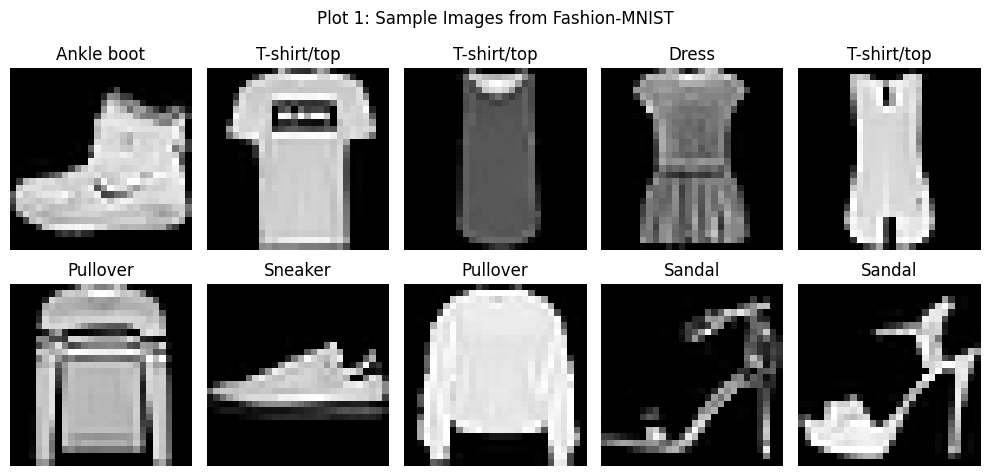

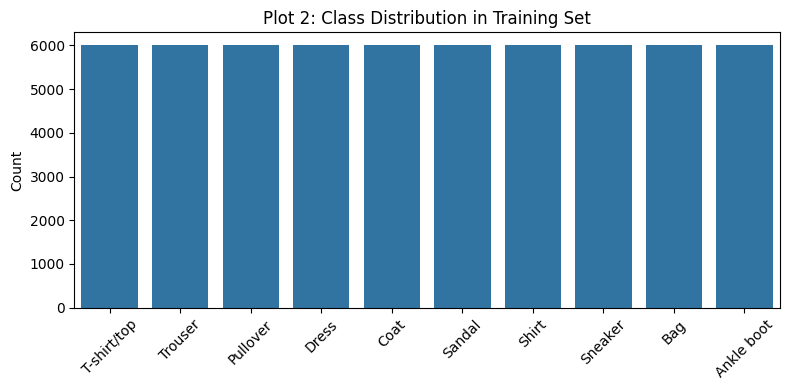

In [ ]:
print("--- Task 1: Dataset Exploration ---")
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

print(f"Train images shape: {X_train_raw.shape}")
print(f"Train labels shape: {y_train_raw.shape}")
print(f"Test images shape: {X_test_raw.shape}")
print(f"Test labels shape: {y_test_raw.shape}\n")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot 1: Sample Images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(class_names[y_train_raw[i]])
    plt.axis('off')
plt.suptitle("Plot 1: Sample Images from Fashion-MNIST")
plt.tight_layout()
plt.show()

# Plot 2: Class Distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=[class_names[i] for i in y_train_raw], order=class_names)
plt.title("Plot 2: Class Distribution in Training Set")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
print("--- Task 2: Data Preprocessing ---")
print(f"Shapes Before Preprocessing: X_train: {X_train_raw.shape}, y_train: {y_train_raw.shape}")

# Normalize pixel values to [0, 1]
X_train_norm = X_train_raw.astype('float32') / 255.0
X_test_norm = X_test_raw.astype('float32') / 255.0

# Flatten images for the baseline MLP input layer
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

# One-hot encode labels
y_train_onehot = to_categorical(y_train_raw, 10)
y_test_onehot = to_categorical(y_test_raw, 10)

print(f"Shapes After Preprocessing: X_train_flat: {X_train_flat.shape}, y_train_onehot: {y_train_onehot.shape}\n")

--- Task 2: Data Preprocessing ---
Shapes Before Preprocessing: X_train: (60000, 28, 28), y_train: (60000,)
Shapes After Preprocessing: X_train_flat: (60000, 784), y_train_onehot: (60000, 10)



In [ ]:
print("--- Tasks 3 & 4: Baseline Model Construction & Training ---")
baseline_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.summary()

baseline_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Time the baseline training
start_time = time.time()
baseline_history = baseline_model.fit(
    X_train_flat, y_train_onehot,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
baseline_time = time.time() - start_time

--- Tasks 3 & 4: Baseline Model Construction & Training ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8178 - loss: 0.5117 - val_accuracy: 0.8526 - val_loss: 0.4167
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8640 - loss: 0.3763 - val_accuracy: 0.8628 - val_loss: 0.3680
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8761 - loss: 0.3388 - val_accuracy: 0.8717 - val_loss: 0.3574
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8843 - loss: 0.3137 - val_accuracy: 0.8767 - val_loss: 0.3449
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8905 - loss: 0.2932 - val_accuracy: 0.8758 - val_loss: 0.3503
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8962 - loss: 0.2766 - val_accuracy: 0.8733 - val_loss: 0.3616
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9027 - loss: 0.2635 - val_accuracy: 0.8777 - val_loss: 0.3536
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9061 - loss: 0.2509 -

--- Task 5: Baseline Model Evaluation ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

[Baseline] Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.76      0.80      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.82      0.78      0.80      1000
       Dress       0.90      0.87      0.88      1000
        Coat       0.74      0.84      0.79      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.68      0.68      0.68      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.92      0.98      0.95      1000
  Ankle boot       0.95      0.97      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



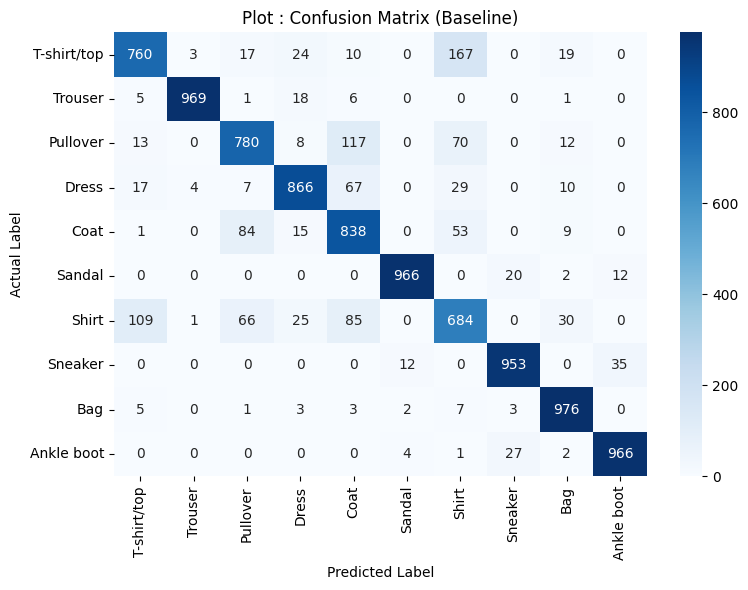

In [ ]:
print("--- Task 5: Baseline Model Evaluation ---")
y_pred_baseline_prob = baseline_model.predict(X_test_flat)
y_pred_baseline = np.argmax(y_pred_baseline_prob, axis=1)

base_acc = accuracy_score(y_test_raw, y_pred_baseline)
base_prec, base_rec, base_f1, _ = precision_recall_fscore_support(y_test_raw, y_pred_baseline, average='macro')

print("\n[Baseline] Classification Report:")
print(classification_report(y_test_raw, y_pred_baseline, target_names=class_names))

# Plot : Confusion Matrix (Baseline)
cm_base = confusion_matrix(y_test_raw, y_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Plot : Confusion Matrix (Baseline)")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

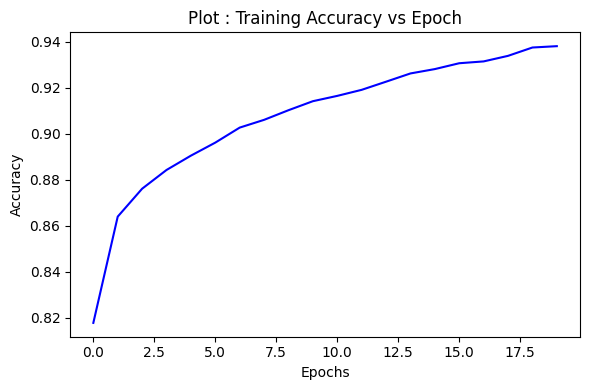

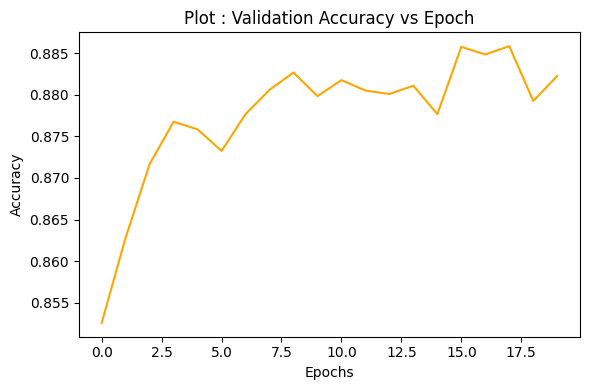

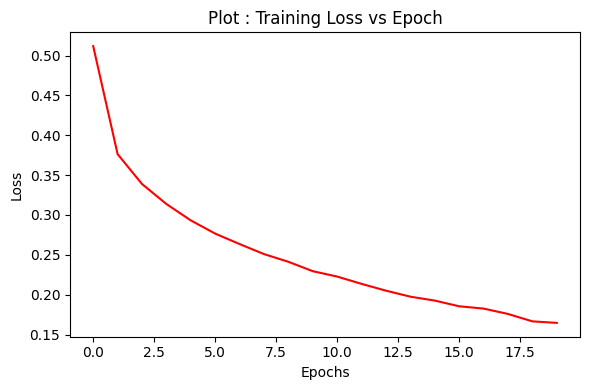

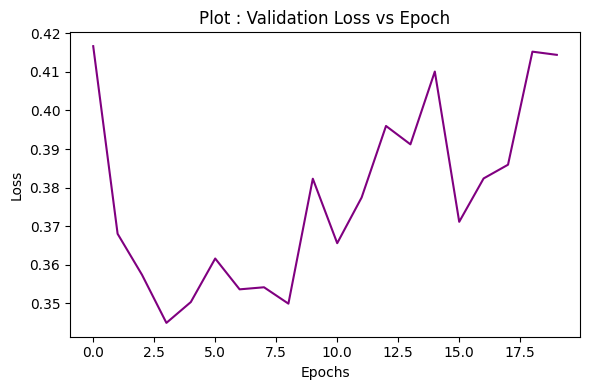

In [ ]:
# Plot : Training Accuracy
plt.figure(figsize=(6, 4))
plt.plot(baseline_history.history['accuracy'], label='Train Accuracy', color='blue')
plt.title("Plot : Training Accuracy vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# Plot : Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot(baseline_history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title("Plot : Validation Accuracy vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# Plot : Training Loss
plt.figure(figsize=(6, 4))
plt.plot(baseline_history.history['loss'], label='Train Loss', color='red')
plt.title("Plot : Training Loss vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

# Plot : Validation Loss
plt.figure(figsize=(6, 4))
plt.plot(baseline_history.history['val_loss'], label='Val Loss', color='purple')
plt.title("Plot : Validation Loss vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [ ]:
print("--- Hyperparameter Optimization ---")

# Dynamic model builder function for SciKeras
def create_mlp_model(hidden_layers=1, hidden_neurons=64, learning_rate=0.001,
                     optimizer='Adam', activation_func='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation_func))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    if optimizer.lower() == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer.lower() == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer.lower() == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Sampling a subset of 10k items for search space exploration to manage Colab runtime constraints
X_tune_subset = X_train_flat[:10000]
y_tune_subset = y_train_onehot[:10000]
keras_clf = KerasClassifier(
    model=create_mlp_model,
    verbose=0,
    model__hidden_layers=1,
    model__hidden_neurons=64,
    model__learning_rate=0.001,
    model__optimizer='Adam',
    model__activation_func='relu',
    model__dropout_rate=0.0
)

# Search space definition matching the initialized model prefixes
param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__optimizer': ['SGD', 'Adam', 'RMSProp'],
    'model__activation_func': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30]
}

print("Executing Randomized Search CV (5-Fold)...")
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    n_jobs=1,
    random_state=42,
    error_score='raise'
)

random_search.fit(X_tune_subset, y_tune_subset)
best_params = random_search.best_params_
cv_best_score = random_search.best_score_

print(f"\nOptimization Complete.")
print(f"Best Configuration: {best_params}")

--- Hyperparameter Optimization ---
Executing Randomized Search CV (5-Fold)...


/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Optimization Complete.
Best Configuration: {'model__optimizer': 'Adam', 'model__learning_rate': 0.001, 'model__hidden_neurons': 256, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation_func': 'tanh', 'epochs': 20, 'batch_size': 32}


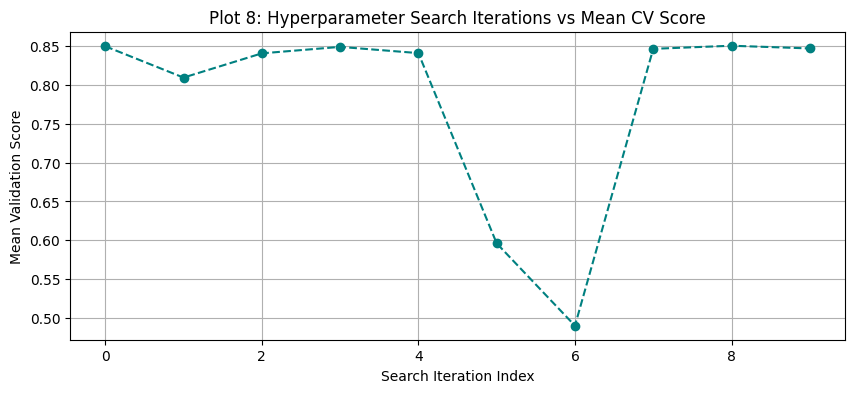

In [ ]:
cv_results_df = pd.DataFrame(random_search.cv_results_)
plt.figure(figsize=(10, 4))
plt.plot(cv_results_df['mean_test_score'], marker='o', linestyle='dashed', color='teal')
plt.title("Plot 8: Hyperparameter Search Iterations vs Mean CV Score")
plt.xlabel("Search Iteration Index")
plt.ylabel("Mean Validation Score")
plt.grid(True)
plt.show()

In [ ]:
print("--- Retraining Optimized Model ---")

opt_model = create_mlp_model(
    hidden_layers=best_params['model__hidden_layers'],
    hidden_neurons=best_params['model__hidden_neurons'],
    learning_rate=best_params['model__learning_rate'],
    optimizer=best_params['model__optimizer'],
    activation_func=best_params['model__activation_func'],
    dropout_rate=best_params['model__dropout_rate']
)

# Track optimization wall time over the full training dataset
start_time = time.time()
opt_model.fit(
    X_train_flat, y_train_onehot,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1
)
opt_time = time.time() - start_time

# Evaluate optimized metrics
y_pred_opt_prob = opt_model.predict(X_test_flat)
y_pred_opt = np.argmax(y_pred_opt_prob, axis=1)

opt_acc = accuracy_score(y_test_raw, y_pred_opt)
opt_prec, opt_rec, opt_f1, _ = precision_recall_fscore_support(y_test_raw, y_pred_opt, average='macro')

--- Retraining Optimized Model ---
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8020 - loss: 0.5463
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8452 - loss: 0.4290
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8556 - loss: 0.3966
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8624 - loss: 0.3759
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8676 - loss: 0.3631
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8709 - loss: 0.3509
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8723 - loss: 0.3481
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8756 - loss: 0.3402
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8769 - loss: 0.3341
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8796 - loss: 0.3282
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8808 - loss: 0

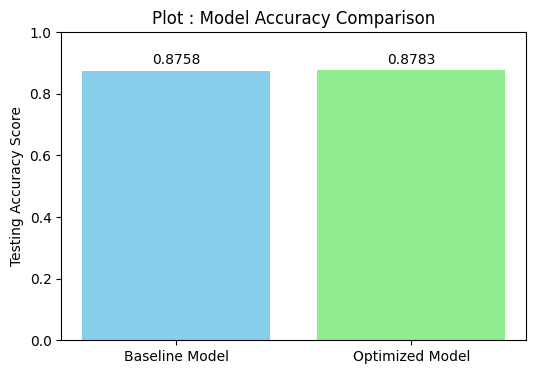

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(['Baseline Model', 'Optimized Model'], [base_acc, opt_acc], color=['skyblue', 'lightgreen'])
plt.ylabel('Testing Accuracy Score')
plt.title('Plot : Model Accuracy Comparison')
plt.ylim(0, 1.0)
for index, value in enumerate([base_acc, opt_acc]):
    plt.text(index, value + 0.02, f"{value:.4f}", ha='center')
plt.show()

In [ ]:
print("\n" + "="*45)
print("TABLE 1: BEST HYPERPARAMETERS SUMMARY")
print("="*45)
table1_data = {
    "Hyperparameter Parameter": [
        "Hidden Layers", "Hidden Neurons", "Learning Rate", "Batch Size",
        "Optimizer", "Activation Function", "Epochs", "Dropout Rate",
        "Cross-validation Accuracy", "Final Testing Accuracy"
    ],
    "Selected Value": [
        best_params['model__hidden_layers'],
        best_params['model__hidden_neurons'],
        best_params['model__learning_rate'],
        best_params['batch_size'],
        best_params['model__optimizer'],
        best_params['model__activation_func'],
        best_params['epochs'],
        best_params['model__dropout_rate'],
        f"{cv_best_score:.4f}",
        f"{opt_acc:.4f}"
    ]
}
print(pd.DataFrame(table1_data).to_string(index=False))

print("\n" + "="*45)
print("TABLE 2: ARCHITECTURE PERFORMANCE METRIC COMPARISON")
print("="*45)
table2_data = {
    "Evaluation Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Training Time (s)"],
    "Baseline Configuration": [f"{base_acc:.4f}", f"{base_prec:.4f}", f"{base_rec:.4f}", f"{base_f1:.4f}", f"{baseline_time:.2f}"],
    "Optimized Configuration": [f"{opt_acc:.4f}", f"{opt_prec:.4f}", f"{opt_rec:.4f}", f"{opt_f1:.4f}", f"{opt_time:.2f}"]
}
print(pd.DataFrame(table2_data).to_string(index=False))


TABLE 1: BEST HYPERPARAMETERS SUMMARY
 Hyperparameter Parameter Selected Value
            Hidden Layers              3
           Hidden Neurons            256
            Learning Rate          0.001
               Batch Size             32
                Optimizer           Adam
      Activation Function           tanh
                   Epochs             20
             Dropout Rate            0.2
Cross-validation Accuracy         0.8504
   Final Testing Accuracy         0.8783

TABLE 2: ARCHITECTURE PERFORMANCE METRIC COMPARISON
Evaluation Metric Baseline Configuration Optimized Configuration
         Accuracy                 0.8758                  0.8783
        Precision                 0.8772                  0.8800
           Recall                 0.8758                  0.8783
         F1-score                 0.8759                  0.8785
Training Time (s)                 132.81                  123.85
